In [15]:
import os

import h5py

import numpy as np
import pandas as pd

from bokeh.models import ColumnDataSource, DataRange1d, HoverTool, LinearAxis
from bokeh.palettes import d3
from bokeh.plotting import figure, show
from bokeh.io import output_notebook

import matplotlib.pyplot as plt

output_notebook()

Loading BokehJS ...

In [16]:
# Define import data folder and data filename
data_folder = './'  # Add your name here, if you're on windows: D:/My Data/Example/

# This is the HDF5 file
data_filename = 'segment_81222.h5'

# Load HDF5 raw data
with h5py.File(os.path.join(data_folder, data_filename), 'r') as data:

    # Get timestamps
    ts_gnss = data['sensor/gnss/timestamp'][:]
    ts_imu = data['sensor/imu/timestamp'][:]
    ts_bar = data['sensor/bar/timestamp'][:]

    # IMU data
    imu_data = {
        'acc': data['sensor/imu/acc'][:, :],
        'gyr': data['sensor/imu/gyr'][:, :]
    }

    # Get the GNSS data. The fields are described in the UBX-NAV-PVT package defintion. 
    # Check the ublox M10 receiver documentation for details
    gnss_data = {
        'lat': data['sensor/gnss/lat'][:],
        'lon': data['sensor/gnss/lon'][:],
        'height_ellipsoid': data['sensor/gnss/height_ellipsoid'][:],
        'height_msl': data['sensor/gnss/height_msl'][:],
        'ground_speed': data['sensor/gnss/ground_speed'][:],
        'vel_east': data['sensor/gnss/vel_east'][:],
        'vel_north': data['sensor/gnss/vel_north'][:],
        'vel_down': data['sensor/gnss/vel_down'][:],
        'speed_acc': data['sensor/gnss/speed_acc'][:],
        'horizontal_acc': data['sensor/gnss/horizontal_acc'][:],
        'vertical_acc': data['sensor/gnss/vertical_acc'][:],
        'heading_acc': data['sensor/gnss/heading_acc'][:],
        'time_acc': data['sensor/gnss/time_acc'][:],
        'timestamp': data['sensor/gnss/timestamp'][:],
        'year': data['sensor/gnss/year'][:],
        'month': data['sensor/gnss/month'][:],
        'day': data['sensor/gnss/day'][:],
        'hour': data['sensor/gnss/hour'][:],
        'min': data['sensor/gnss/min'][:],
        'sec': data['sensor/gnss/sec'][:],
        'nano': data['sensor/gnss/nano'][:],
        'itow': data['sensor/gnss/itow'][:],
        'nb_sats': data['sensor/gnss/nb_sats'][:],
        'position_dop': data['sensor/gnss/position_dop'][:],
        'heading': data['sensor/gnss/heading'][:],
        'fix_type': data['sensor/gnss/fix_type'][:],
        'flags': data['sensor/gnss/flags'][:],
        'flags2': data['sensor/gnss/flags2'][:]
    }

    # Barometric pressure sensor data
    data_bar = {
        'pres': data['sensor/bar/pres'][:],
        'temp': data['sensor/bar/temp'][:]
    }

print('Data Loading Completed')

Data Loading Completed


In [17]:
# Plot every 10th sample of the acceleration data
p = figure(width=800, height=300, title='Subsampled Raw Acceleration')
p.line(ts_imu[::10], imu_data['acc'][::10, 0], color='#0033ff', legend_label='x')
p.line(ts_imu[::10], imu_data['acc'][::10, 1], color='#cc3300', legend_label='y')
p.line(ts_imu[::10], imu_data['acc'][::10, 2], color='#ffcc00', legend_label='z')
p.xaxis.axis_label = 'Time, sec'
p.yaxis.axis_label = 'Acceleration, m/s2'
show(p)

In [18]:
# Plot the GNSS ground speed
p = figure(width=800, height=300, title='GNSS Ground Speed')
p.line(ts_gnss, gnss_data['ground_speed'], color='#0033ff')
p.xaxis.axis_label = 'Time, sec'
p.yaxis.axis_label = 'Ground Speed, m/s'
show(p)

In [19]:
# Define import data folder and data filename
data_folder = './'  # Add your name here, if you're on windows: D:/My Data/Example/

# This is the segment HDF5 file, can be downloaded on the webapp, by opening the segment and clicking on the
# "Export to HDF5" button
segment_id = 81222
data_filename = 'segment_{:d}.h5'.format(segment_id)

# Load HDF5 segment data
with h5py.File(os.path.join(data_folder, data_filename), 'r') as data:

    # This would get the instantaneous COM position and speed (not needed for the CSV export)
    ts_com = data['processed/com/timestamp'][:]
    p_com = data['processed/com/pos'][:, :]
    v_com = data['processed/com/vel'][:, :]
    turn_radius = data['processed/com/turn_radius'][:]  # Alpine skiing only

    # Get the position offset to put the measured data to the absolute UTM reference frame
    pos_offset = data['processed/com/pos_offset'][:]

    print(data['processed'].keys())

    # Load the turn switch data (alpine only)
    turn_switch_inds = data['processed/turn_stats/turn_switches'][:].astype(int)
    
p_com += pos_offset
ts_com -= ts_com[0]

<KeysViewHDF5 ['com', 'turn_stats']>


In [57]:
dp = np.diff(p_com, axis=0)                 # (N-1, 3)
ds = np.linalg.norm(dp, axis=1)             # (N-1,)   metri tra campioni

s = np.concatenate(([0.0], np.cumsum(ds)))  # (N,)     distanza cumulata in metri
dist_tot = s[-1]

print("Distanza totale [m]:", dist_tot)

dt = np.diff(ts_com)

print("Primi dt:", dt[:10])
print("dt medio [s]:", np.mean(dt))
print("dt std  [s]:", np.std(dt))

dp = np.diff(p_com, axis=0)
ds = np.linalg.norm(dp, axis=1)   # spostamento tra campioni

# differenze temporali
dt = np.diff(ts_com)

# velocità ricostruita da spostamento
v = ds / dt

# ascissa curvilinea integrando v dt
s = np.zeros_like(ts_com)
s[1:] = np.cumsum(v * dt)

dist_tot = s[-1]

print("Distanza totale [m]:", dist_tot)


print("Shape p_com:", p_com.shape)
print("Shape dt:", dt.shape)
dx_dt = np.gradient(p_com[:,0], ts_com)
dy_dt = np.gradient(p_com[:,1], ts_com)
dz_dt = np.gradient(p_com[:,2], ts_com)
ds = np.sqrt(dx_dt**2 + dy_dt**2 + dz_dt**2)[1:]*dt
s = np.cumsum(ds)
dist_tot = s[-1]
print("Distanza totale [m]:", dist_tot)

dt = np.diff(ts_com)

print("dt min:", dt.min())
print("quanti dt==0:", np.sum(dt == 0))
print("quanti dt<0:", np.sum(dt < 0))

# dove succede
zero_idx = np.where(dt == 0)[0]
print("prime posizioni con dt=0:", zero_idx[:20])



Distanza totale [m]: 308.94620857218706
Primi dt: [0.005 0.005 0.005 0.005 0.005 0.005 0.005 0.005 0.005 0.005]
dt medio [s]: 0.005000000000109139
dt std  [s]: 0.0
Distanza totale [m]: 308.94620857218706
Shape p_com: (5899, 3)
Shape dt: (5898,)
Distanza totale [m]: 308.9760387307534
dt min: 0.005000000000109139
quanti dt==0: 0
quanti dt<0: 0
prime posizioni con dt=0: []


In [ ]:
data_folder = './'
segment_id = 81222
data_filename = 'segment_{:d}.h5'.format(segment_id)

with h5py.File(os.path.join(data_folder, data_filename), 'r') as data:
    print(data['processed/com/'].keys())
    print(data['processed/com/pos'][:])
    data['sensor/gnss/sec'][:],

<KeysViewHDF5 ['gnss_time_offset', 'inclination', 'p_antenna_com', 'pos', 'pos_offset', 'q_sensor', 'timestamp', 'turn_radius', 'vel']>
[[ 3.68495089e-02 -7.39955068e-02 -2.20379474e-01]
 [ 3.65456745e-02 -7.43132088e-02 -2.20345119e-01]
 [ 3.62348494e-02 -7.46391321e-02 -2.20313034e-01]
 ...
 [-2.64656512e+02  4.83944955e+01 -9.11748948e+01]
 [-2.64713439e+02  4.84116428e+01 -9.11893471e+01]
 [-2.64770467e+02  4.84285189e+01 -9.12039864e+01]]


In [43]:
t = gnss_data['sec']
#timestamp

print("shape:", t.shape)
print("primi valori:", t[:5])
print("ultimi valori:", t[-5:])
print("dt medio:", np.mean(np.diff(t)))


shape: (292,)
primi valori: [25. 25. 25. 25. 25.]
ultimi valori: [54. 54. 54. 54. 54.]
dt medio: 0.09965635738831616


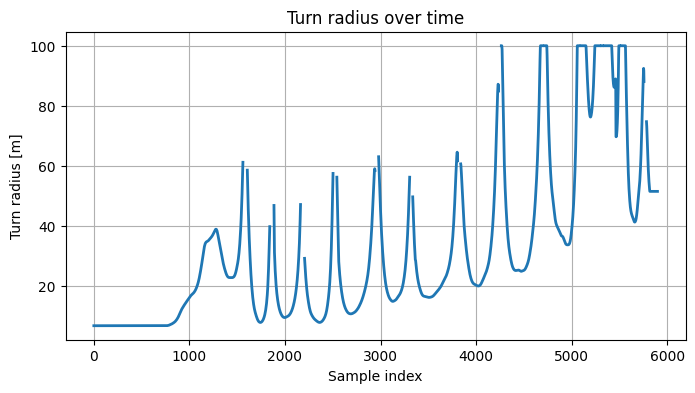

In [20]:
plt.figure(figsize=(8,4))
plt.plot(turn_radius, lw=2)
plt.xlabel('Sample index')
plt.ylabel('Turn radius [m]')
plt.title('Turn radius over time')
plt.grid(True)
plt.show()